# second updated version 
- edited 06/22
- re-run with the newer version of snRNA (with d=4 for the batch corrections)
- only use the selected population of merfish cells. 
- add the quality score etc and summarize 
- potentially the same notebook should be used for the BARseq analysis

in words description 

> we define a “baseline” distance by randomly pairing snRNAseq and MERFISH cells, then see how much closer each MERFISH cell’s k nearest snRNA neighbors are (on average) compared to that baseline. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

# 
# markergenes = ['Dbh', 'Th', 'Slc6a2']

In [3]:
import glob, os, sys
from scipy.io import mmread
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import imputations,utils

allmeshes = utils.load_mesh()
mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
mesh.vertices /= 25
allmeshes


{'250513_LC_core_67_mesh_shrunk': <trimesh.Trimesh(vertices.shape=(19148, 3), faces.shape=(38292, 3))>}

# snRNAseq

In [4]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_d4.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

In [5]:
adata_sc.var_names.str.startswith("mt-").sum()

np.int64(12)

In [6]:
adata_sc.var_names.str.startswith(("Rps", "Rpl")).sum()

np.int64(5)

In [7]:
adata_sc.var["mt"] = adata_sc.var_names.str.startswith("mt-")
adata_sc.var["ribo"] = adata_sc.var_names.str.startswith(("Rps", "Rpl"))


In [8]:
sc.pp.calculate_qc_metrics(
    adata_sc, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

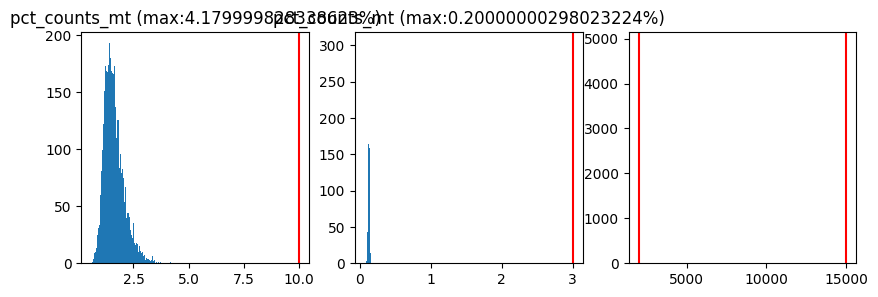

In [9]:
plt.figure(figsize = (10,3))
plt.subplot(1,3,1);
plt.hist(adata_sc.obs['pct_counts_mt'].values.flatten(), bins = 100);
plt.axvline(10, color = 'red')
maxv= np.around(adata_sc.obs['pct_counts_mt'].values.max(), 2)
plt.title(f'pct_counts_mt (max:{maxv}%)')

plt.subplot(1,3,2);
plt.hist(adata_sc.obs['pct_counts_ribo'].values.flatten(), bins = 100);
plt.axvline(3, color = 'red')
maxv= np.around(adata_sc.obs['pct_counts_ribo'].values.max(), 2)
plt.title(f'pct_counts_mt (max:{maxv}%)')

plt.subplot(1,3,3);
plt.hist(adata_sc.obs['n_genes_by_counts'].values.flatten(), bins = 100);
plt.axvline(2000, color = 'red');plt.axvline(15000, color = 'red')

# they all passes the criterion. 


## but lets remove mt and ribo genes. 

In [10]:
mask = ~(adata_sc.var["mt"] | adata_sc.var["ribo"])
adata_sc = adata_sc[:, mask].copy()

# merfish

In [11]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
print(adata_mer.X.max())# do not normalize again.

0.22035266


In [12]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


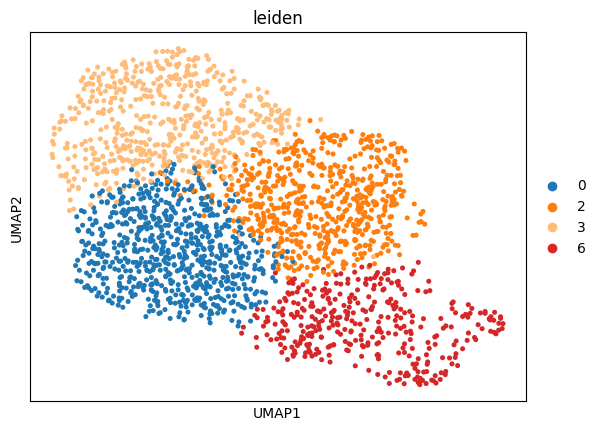

In [13]:
a = sc.pl.umap(adata_mer,color=['leiden'],
               cmap='Reds',ncols=3, show = False,use_raw = False)
# a.set_aspect('equal')

### find the best k based on the correlation on gradient genes!
- this makes sense bc gradient genes are more replesentative on characterizing the imputation results. 
- PC1 genes cannoe be used bc we dont have a GT

In [26]:
intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']

corcoef_dict = dict()
for k in [5,10,30,50,100,200,500, 800, 1000]:
    adata_mer_imputed = imputations.impute_mer_data(adata_sc, adata_mer, k=k, n_hvg=None, n_holdoff_genes=0, random_state=111)
    adata_mer = imputations.replace_imputedvalues(adata_mer,adata_mer_imputed, intersted_genes)
    corr_coef_list = []
    for i,tested_gene in enumerate(intersted_genes):
        x = adata_mer[:, tested_gene].X.flatten()
        y = adata_mer.obs['imput_' + tested_gene].values
        corr_coef_list.append(np.corrcoef(x, y)[0, 1])
    corcoef_dict[k]=corr_coef_list


In [27]:
corcoef_dict.keys()

dict_keys([5, 10, 30, 50, 100, 200, 500, 800, 1000])

In [28]:
list(corcoef_dict.keys())[np.argmax([np.mean(l) for l in (corcoef_dict.values())])]

200

In [29]:
np.mean(corcoef_dict[100]),np.mean(corcoef_dict[200])

(np.float64(0.6501720426438118), np.float64(0.6513191364822178))

Text(0, 0.5, 'mean corcoeff')

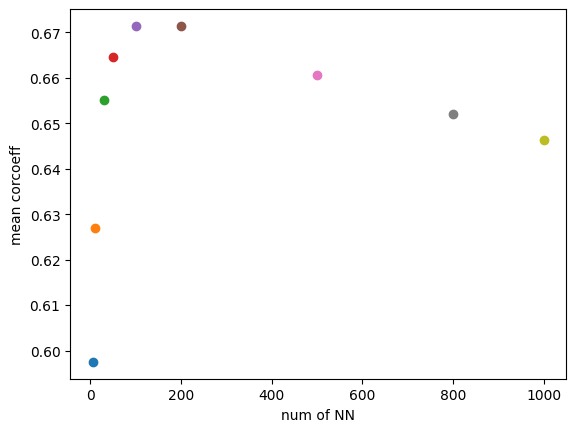

In [21]:
for k, v in corcoef_dict.items():
    plt.scatter(k, np.mean(v), )
plt.xlabel('num of NN')    

plt.ylabel('mean corcoeff')    

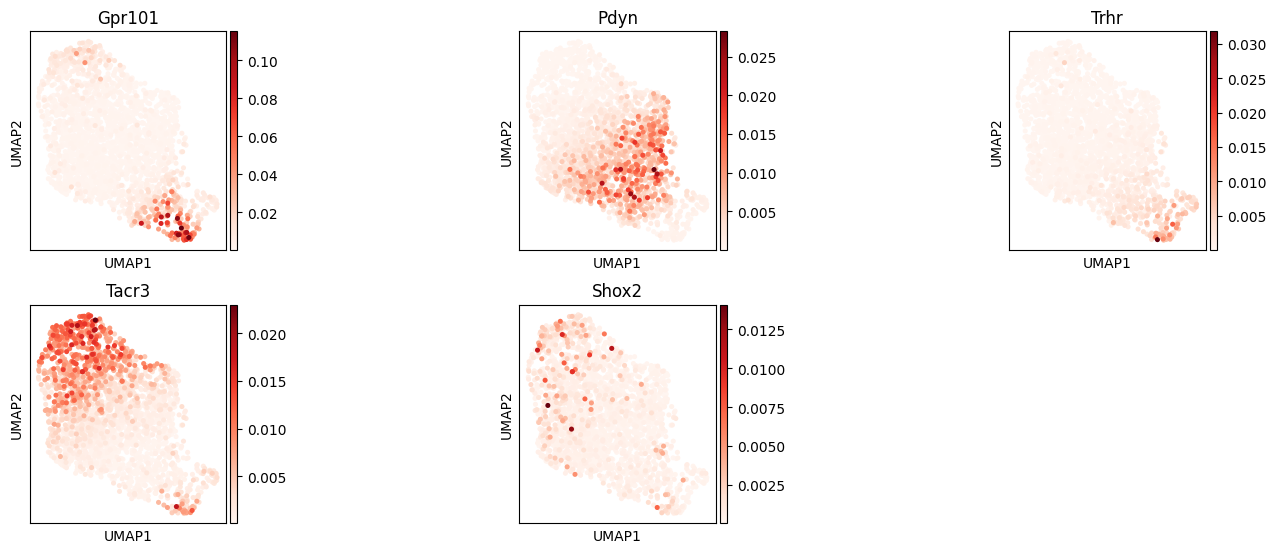

In [30]:
with plt.rc_context({"figure.figsize": (5,3)}):
    ax = sc.pl.umap(adata_mer,color=intersted_genes,
               cmap='Reds',ncols=3, show = False,
               use_raw = False)
    for a in ax:
        a.set_aspect('equal')

/scratch/fast/1339261/ipykernel_3629786/241233082.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend().set_visible(False)
/scratch/fast/1339261/ipykernel_3629786/241233082.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


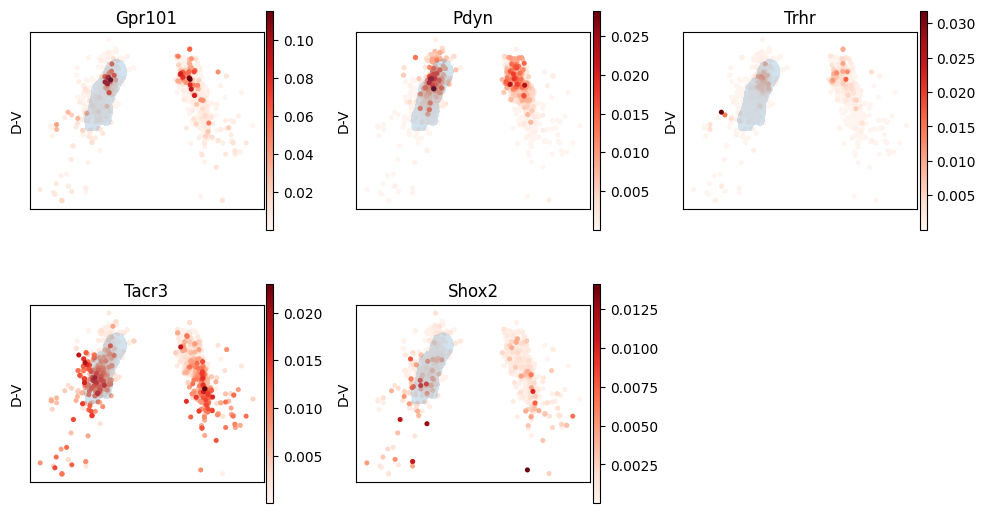

In [38]:
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .2)
        a.invert_yaxis()
        a.set_aspect('equal')
        a.set_aspect('equal')
        a.set_ylabel('D-V')
        a.set_xlabel('')
        a.legend().set_visible(False)
    plt.tight_layout()

/scratch/fast/1339261/ipykernel_3629786/1794193405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend().set_visible(False)
/scratch/fast/1339261/ipykernel_3629786/1794193405.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


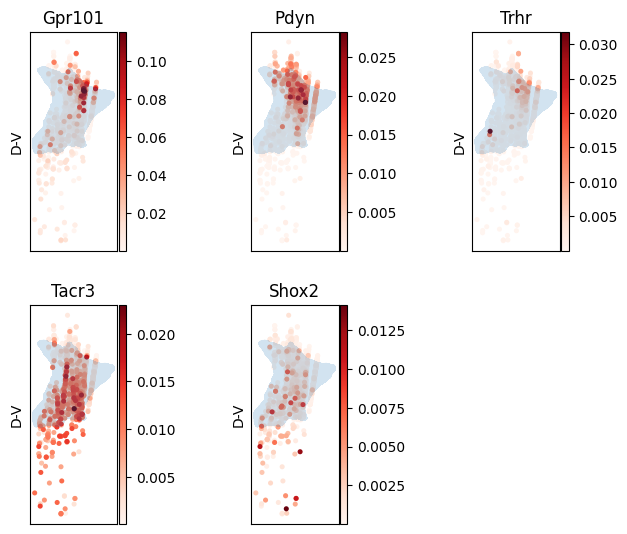

In [40]:
with plt.rc_context({"figure.figsize": (1.7,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (0, 1),basis="spatial", cmap ='Reds',
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha = .2)
        a.invert_yaxis()
        a.set_aspect('equal')
        a.set_aspect('equal')
        a.set_ylabel('D-V')
        a.set_xlabel('')
        a.legend().set_visible(False)
        
    plt.tight_layout()

# RUN IMPUTE!!

In [25]:
n_hvg = None 
k = 100
n_holdoff_genes = 5
random_state = 345

adata_mer_imputed = imputations.impute_mer_data(adata_sc, adata_mer, k=k, 
                                    n_hvg=n_hvg, n_holdoff_genes=n_holdoff_genes, random_state=random_state)

adata_mer.obs = adata_mer_imputed.obs.copy()

In [26]:
adata_mer_imputed.obs.head()

,slicename,x_CCF,y_CCF,z_CCF,mouse_name,mouse_sex,_scvi_batch,_scvi_labels,leiden,sex,impute_quality,not_confident,confidence_vals,frac_vals,conf_percentile,p_scores
neuron_id,,,,,,,,,,,,,,,,
110143770882700220040132120043038831763,MouseC_C2,407.519014,197.276290,266.738031,MouseC,M,0,0,3,M,0.114455,False,100,1.0,0.869,0.869
120882274368051877867511817169740490916,MouseC_C2,405.119627,151.984390,256.980065,MouseC,M,0,0,2,M,0.106056,False,100,1.0,0.844,0.844
123024757869921146658659796693384394846,MouseC_C2,404.933683,148.474425,249.260515,MouseC,M,0,0,3,M,0.082892,False,100,1.0,0.787,0.787
12540531990191327531728358278060678344,MouseC_C2,404.842190,146.747376,252.804036,MouseC,M,0,0,2,M,0.157064,False,100,1.0,0.950,0.950
137945223335615087840559042704487995896,MouseC_C2,407.434045,195.672372,186.680697,MouseC,M,0,0,3,M,0.078406,False,100,1.0,0.774,0.774


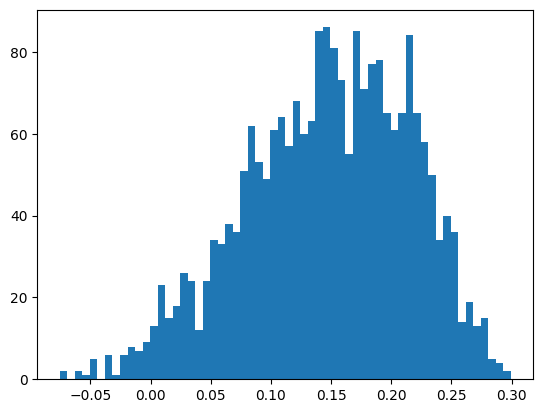

In [30]:
plt.hist(adata_mer_imputed.obs['impute_quality'].values, bins = 60);

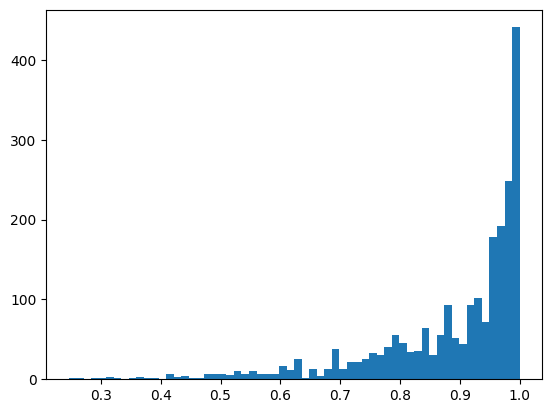

In [29]:
plt.hist(adata_mer_imputed.obs['p_scores'].values, bins = 60);

# so which cells are harder to impute? 

In [31]:
adata_mer.shape, adata_mer_imputed.shape

((2252, 314), (2252, 5109))

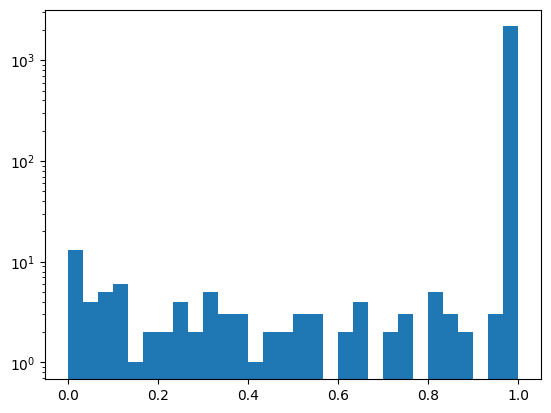

In [55]:
plt.hist(adata_mer_imputed.obs['frac_vals'], bins = 30);
plt.yscale('logs')

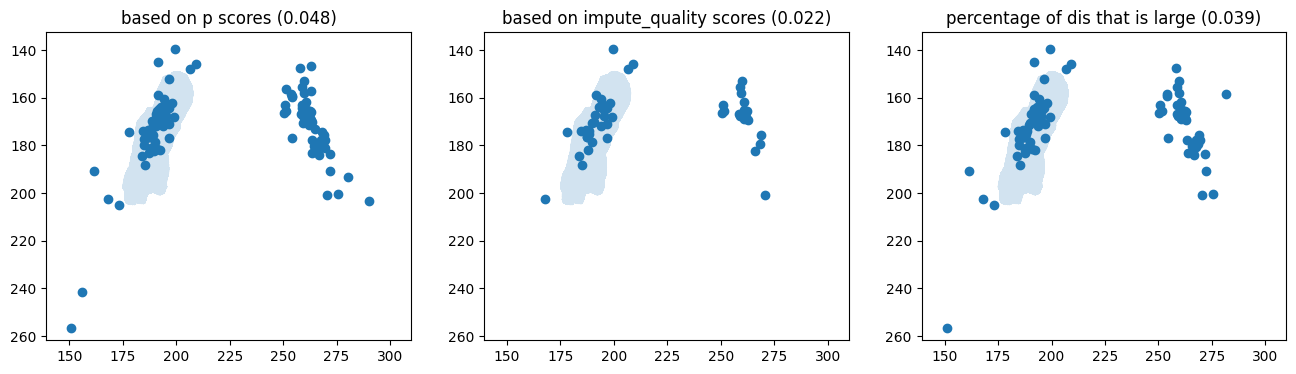

In [62]:
plt.figure(figsize = (16, 4))
plotid = adata_mer_imputed.obs['p_scores']<0.6
plt.subplot(1,3,1)
plt.scatter(adata_mer.obsm['spatial'][plotid,2],adata_mer.obsm['spatial'][plotid,1])
plt.xlim(adata_mer.obsm['spatial'][:,2].min(),adata_mer.obsm['spatial'][:,2].max())
plt.ylim(adata_mer.obsm['spatial'][:,1].min(),adata_mer.obsm['spatial'][:,1].max())
plt.title(f'based on p scores ({np.round((plotid.sum())/adata_mer.shape[0],3)})')
plt.gca().triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .2)
plt.gca().invert_yaxis()

plotid = adata_mer_imputed.obs['impute_quality']<0
plt.subplot(1,3,2)
plt.scatter(adata_mer.obsm['spatial'][plotid,2],adata_mer.obsm['spatial'][plotid,1])
plt.xlim(adata_mer.obsm['spatial'][:,2].min(),adata_mer.obsm['spatial'][:,2].max())
plt.ylim(adata_mer.obsm['spatial'][:,1].min(),adata_mer.obsm['spatial'][:,1].max())
plt.title(f'based on impute_quality scores ({np.round((plotid.sum())/adata_mer.shape[0],3)})')
plt.gca().triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .2)
plt.gca().invert_yaxis()

plotid = adata_mer_imputed.obs['frac_vals']<1
plt.subplot(1,3,3)
plt.scatter(adata_mer.obsm['spatial'][plotid,2],adata_mer.obsm['spatial'][plotid,1])
plt.xlim(adata_mer.obsm['spatial'][:,2].min(),adata_mer.obsm['spatial'][:,2].max())
plt.ylim(adata_mer.obsm['spatial'][:,1].min(),adata_mer.obsm['spatial'][:,1].max())
plt.title(f'percentage of dis that is large ({np.round((plotid.sum())/adata_mer.shape[0],3)})')
plt.gca().triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .2)
plt.gca().invert_yaxis()

In [63]:
plotid.sum()

np.int64(88)

# get teh values for some genes. 

In [113]:
adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, intersted_genes)
adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed,adata_mer_imputed.uns['holdoff_genes'])

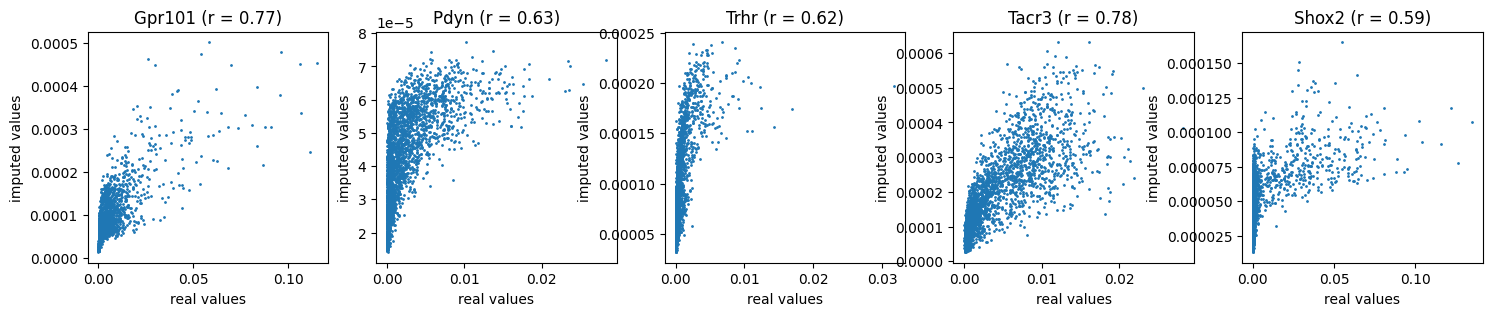

In [114]:
plt.figure(figsize = (18,3))
for i,tested_gene in enumerate(intersted_genes):
    plt.subplot(1,5,i+1)
    x = adata_mer[:, tested_gene].X.flatten()
    y = adata_mer.obs['imput_' + tested_gene].values
    plt.scatter(x, y, s=1)
    
    corr_coef = np.corrcoef(x, y)[0, 1]    
    plt.title(f"{tested_gene} (r = {corr_coef:.2f})")
    plt.ylabel('imputed values')
    plt.xlabel('real values')

# so what would be the distance for some randomly sampled cells? 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


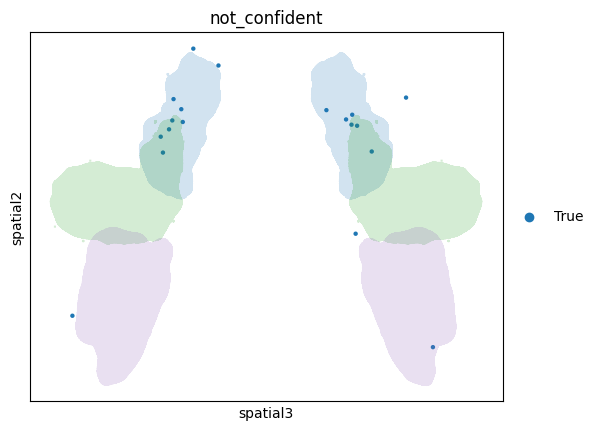

In [115]:
a = sc.pl.embedding(adata_mer_imputed[adata_mer_imputed.obs['not_confident']],show = False,
                dimensions = (2, 1),basis="spatial", color='not_confident', size = 40,)

a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
a.invert_yaxis()
a.set_aspect('equal')


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


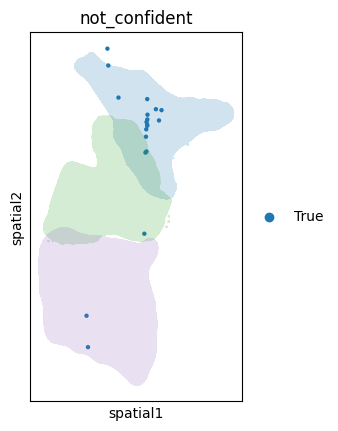

In [116]:
a = sc.pl.embedding(adata_mer_imputed[adata_mer_imputed.obs['not_confident']],show = False,
                dimensions = (0, 1),basis="spatial", color='not_confident', size = 40,)

a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
a.invert_yaxis()
a.set_aspect('equal')


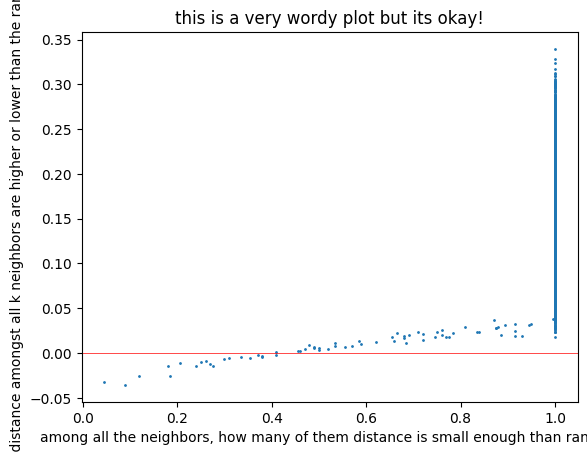

In [120]:
plt.scatter(adata_mer_imputed.obs['confidence_vals'].values/k, adata_mer_imputed.obs['impute_quality'], s=1);
plt.axhline(0, color='red', lw = .5)
plt.xlabel('among all the neighbors, how many of them distance is small enough than random')
plt.ylabel('average distance amongst all k neighbors are higher or lower than the random case!')
plt.title('this is a very wordy plot but its okay!');

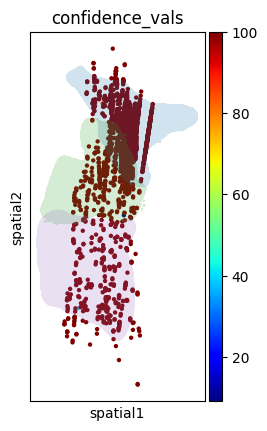

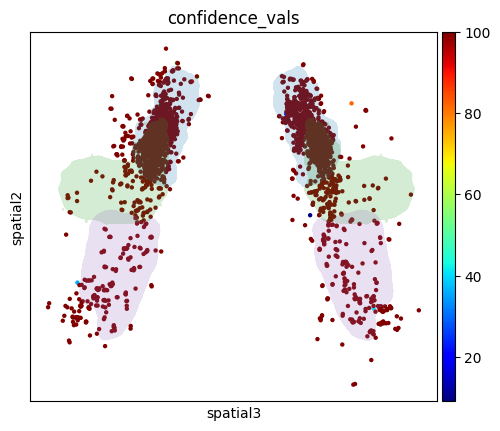

In [104]:
a = sc.pl.embedding(adata_mer_imputed,show = False,
                dimensions = (0, 1),basis="spatial", color='confidence_vals', size = 40, cmap = 'jet')

a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
a.invert_yaxis()
a.set_aspect('equal')


a = sc.pl.embedding(adata_mer_imputed,show = False,
                dimensions = (2, 1),basis="spatial", color='confidence_vals', size = 40, cmap = 'jet',)

a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
a.invert_yaxis()
a.set_aspect('equal')


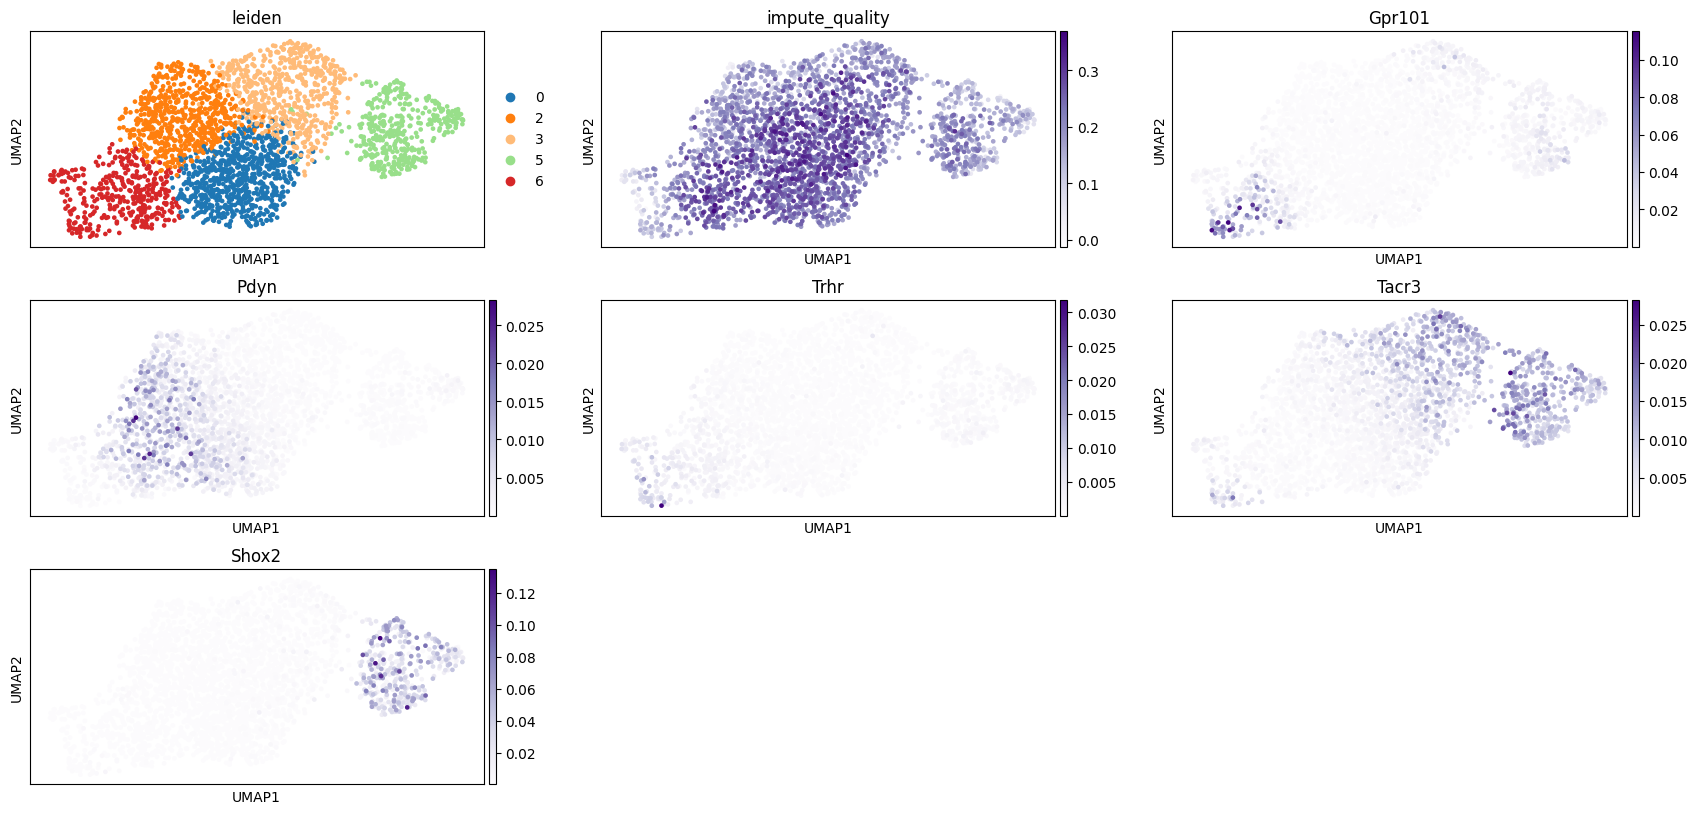

In [55]:
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,color=['leiden', 'impute_quality']+intersted_genes,
           cmap='Purples',ncols=3)


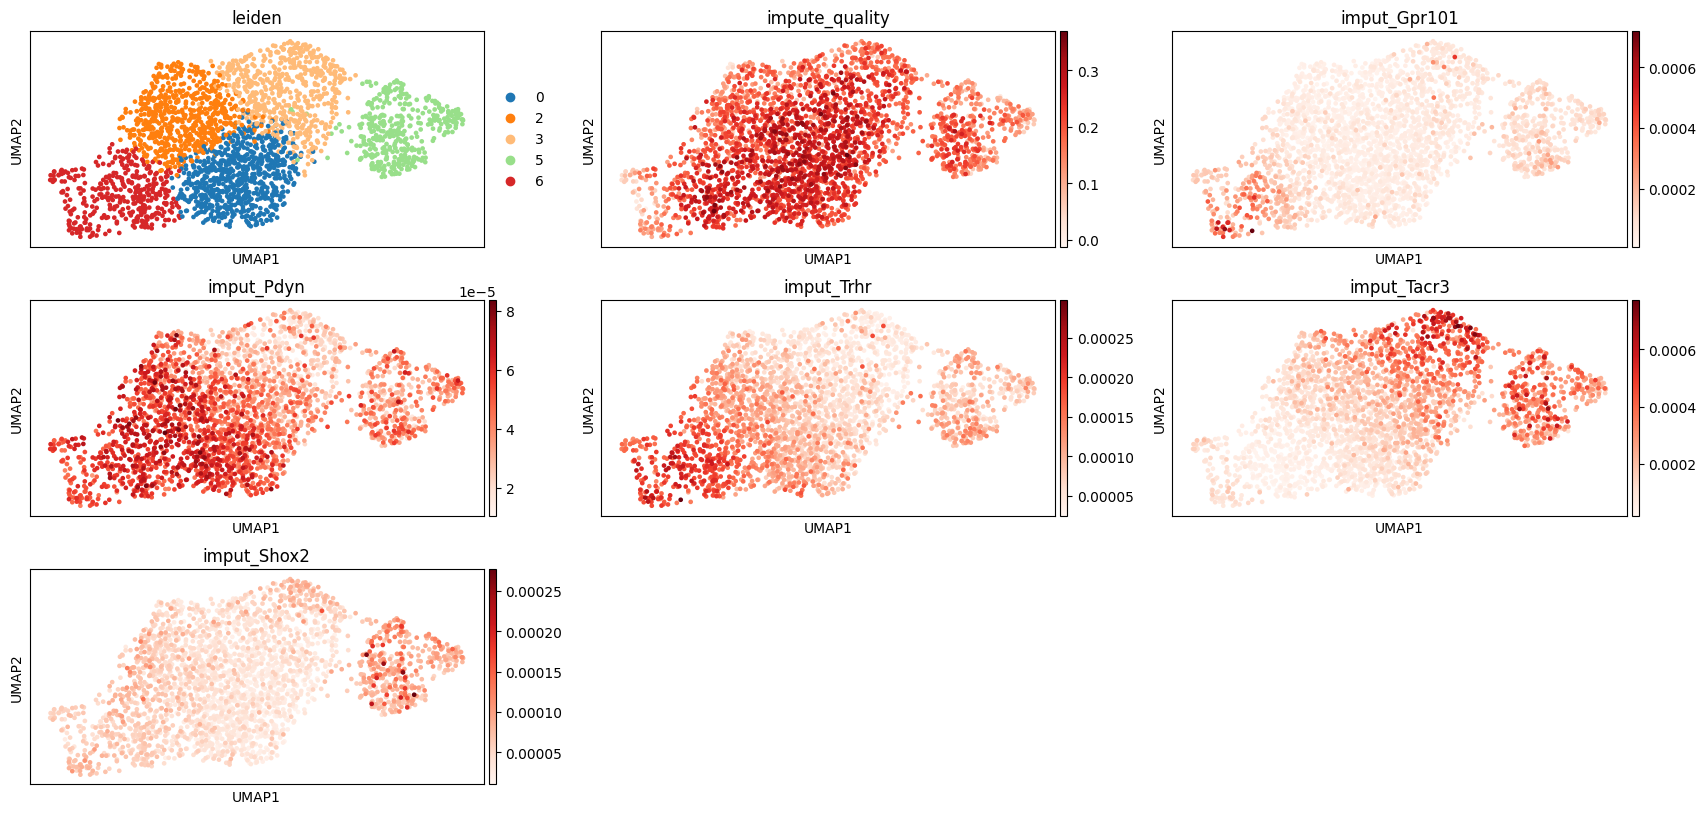

In [56]:


with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = ['leiden', 'impute_quality']+[f'imput_{g}' for g in intersted_genes],           
           cmap='Reds',ncols=3)


/scratch/fast/66059/ipykernel_2428859/1375212877.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


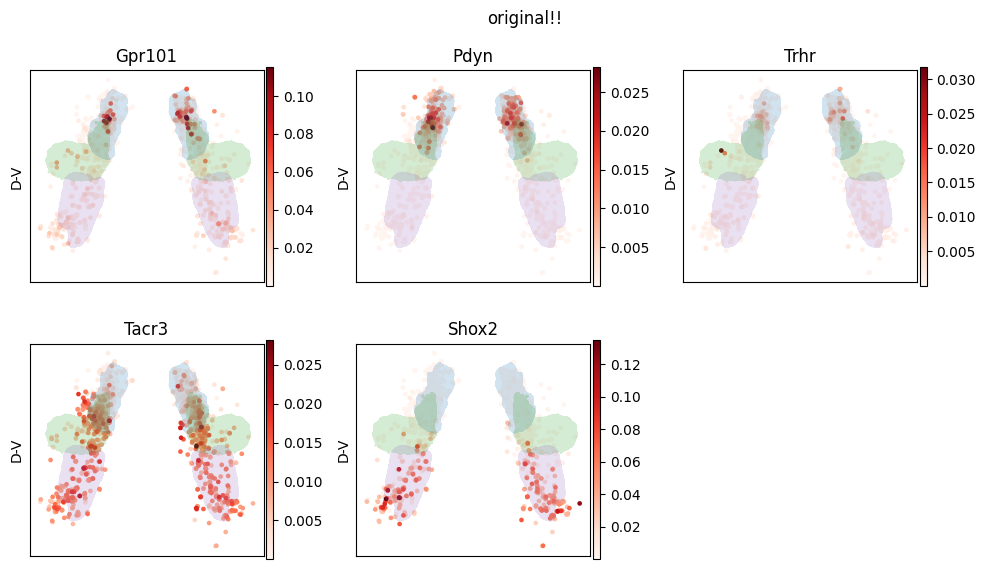

<Figure size 300x300 with 0 Axes>

In [57]:
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
        a.set_ylabel('D-V')
        a.set_xlabel('')
        a.legend().set_visible(False)
    plt.tight_layout()
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    fig.suptitle('original!!')
    plt.show()  
    plt.tight_layout()

/scratch/fast/66059/ipykernel_2428859/527945490.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


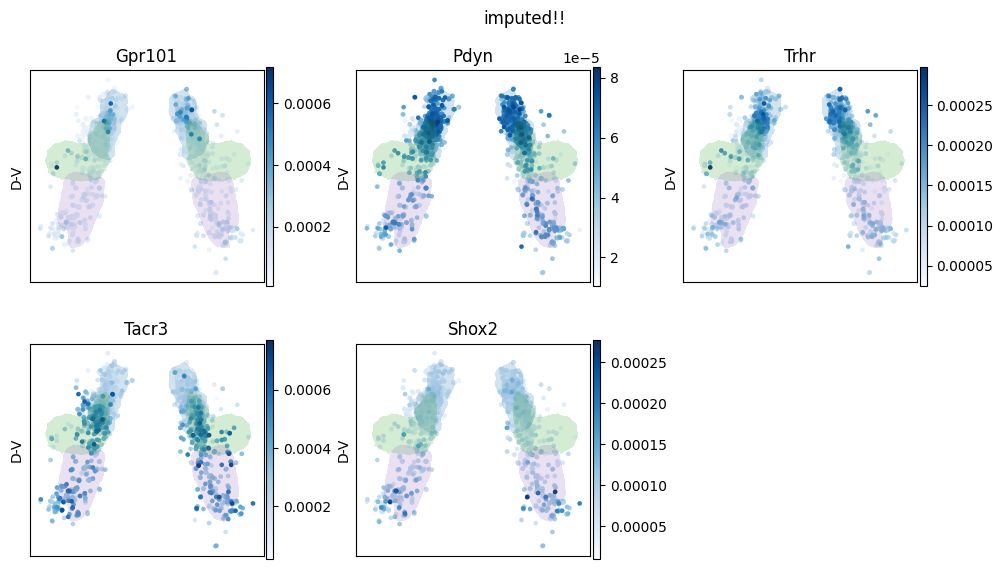

<Figure size 300x300 with 0 Axes>

In [58]:
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer_imputed, dimensions = (2, 1),basis="spatial", cmap ='Blues',
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
        a.set_ylabel('D-V')
        a.set_xlabel('')
        a.legend().set_visible(False)
    plt.tight_layout()
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    fig.suptitle('imputed!!')
    plt.show()    
    plt.tight_layout()

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/scratch/fast/66059/ipykernel_2428859/422634799.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


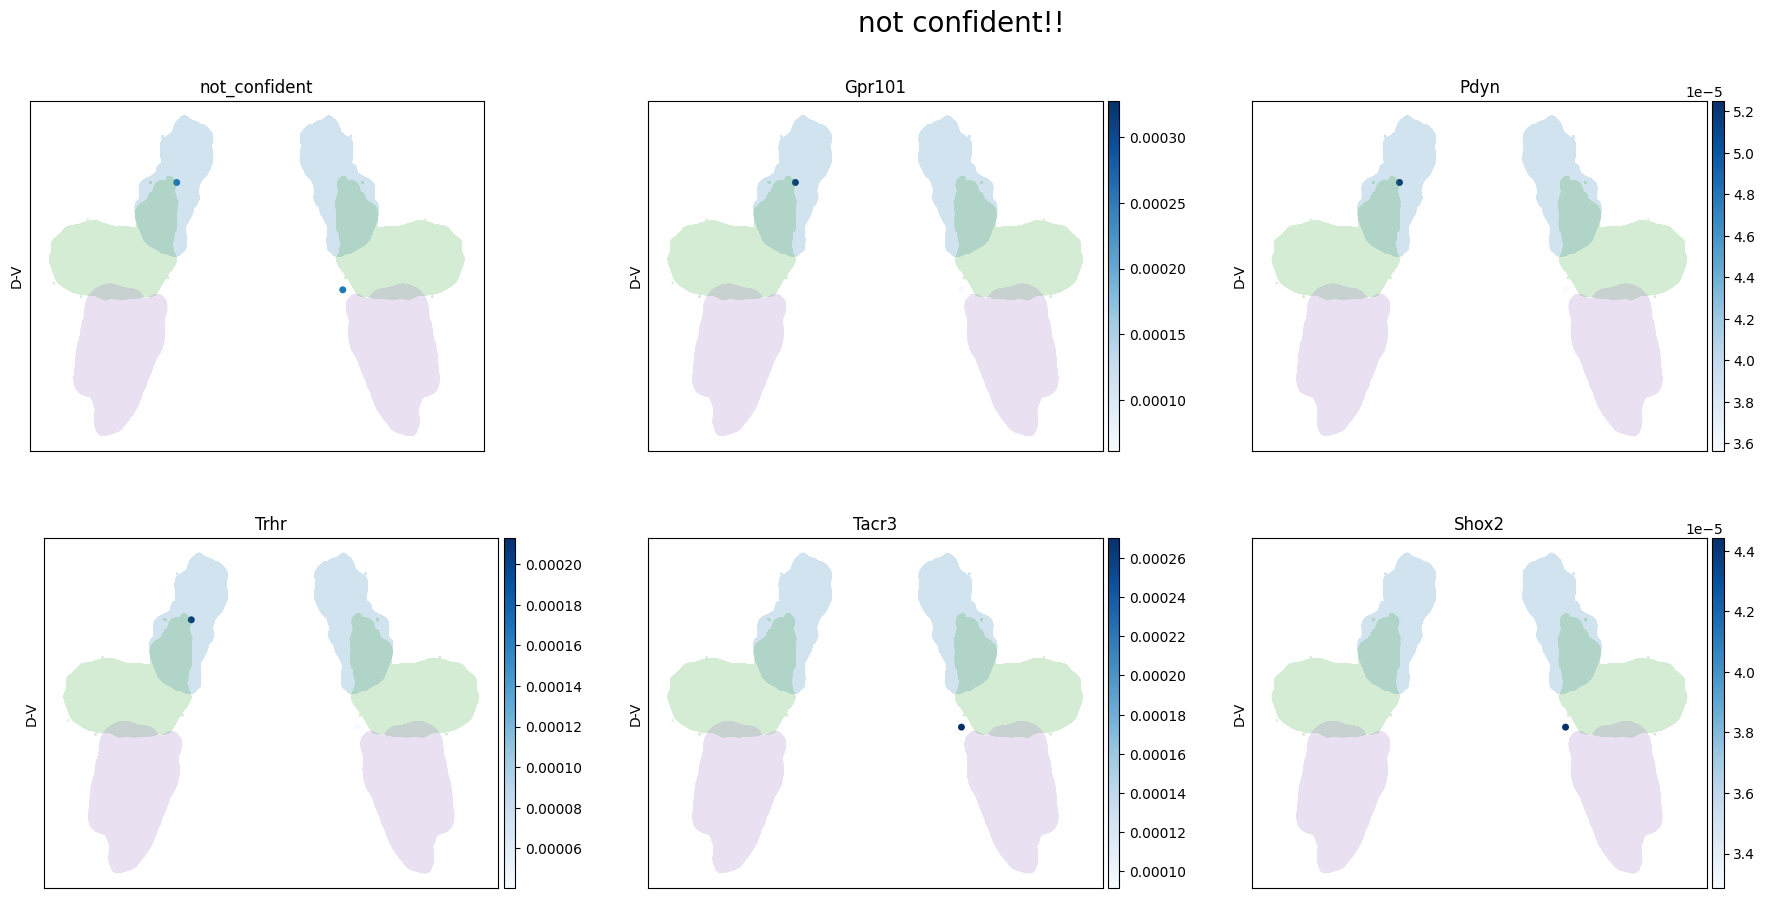

<Figure size 640x480 with 0 Axes>

In [59]:
ax = sc.pl.embedding(adata_mer_imputed[adata_mer_imputed.obs['not_confident']],
                dimensions = (2, 1),basis="spatial", cmap ='Blues',
                color=['not_confident',]+intersted_genes,ncols =3,size = 100,show=False)    

for a in ax:
    a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
    a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
    a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
    a.invert_yaxis()
    a.set_aspect('equal')
    a.set_aspect('equal')
    a.set_ylabel('D-V')
    a.set_xlabel('')
    a.legend().set_visible(False)
plt.tight_layout()
fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
fig.suptitle('not confident!!', fontsize =20)
plt.show()    
plt.tight_layout()    

In [42]:
adata_mer_imputed.obs['not_confident'].sum()

np.int64(19)

In [43]:
adata_mer_imputed.shape

(2651, 1989)

In [44]:
adata_mer_imputed.obs.head()

,slicename,x_CCF,y_CCF,z_CCF,mouse_name,mouse_sex,_scvi_batch,_scvi_labels,leiden,sex,new leiden!,imput_Gpr101,imput_Pdyn,imput_Trhr,imput_Tacr3,imput_Shox2,impute_quality,not_confident
neuron_id,,,,,,,,,,,,,,,,,,
103685216640203968188516774531086347883,MouseC_C2,409.606844,236.687088,179.309040,MouseC,M,0,0,5,M,3,0.000167,0.000044,0.000106,0.000239,0.000074,0.106866,False
107556232960175669029944473037950900912,MouseC_C2,409.104832,227.210884,174.501084,MouseC,M,0,0,5,M,3,0.000098,0.000034,0.000078,0.000271,0.000065,0.172783,False
110143770882700220040132120043038831763,MouseC_C2,407.519014,197.276290,266.738031,MouseC,M,0,0,3,M,2,0.000045,0.000024,0.000057,0.000359,0.000035,0.163896,False
113385467015087615676147138608792183276,MouseC_C2,410.125922,246.485426,165.601449,MouseC,M,0,0,5,M,3,0.000099,0.000033,0.000081,0.000300,0.000080,0.149502,False
120882274368051877867511817169740490916,MouseC_C2,405.119627,151.984390,256.980065,MouseC,M,0,0,2,M,8,0.000049,0.000031,0.000066,0.000263,0.000040,0.157783,False


Text(0.5, 1.0, 'impute quality scores!')

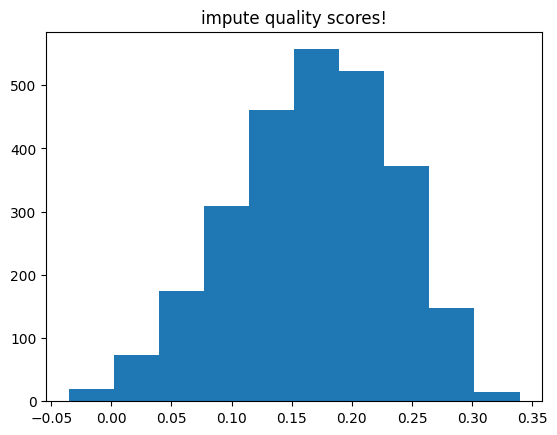

In [45]:
plt.hist(adata_mer_imputed.obs['impute_quality']);
plt.title('impute quality scores!')

# now use the validation set to check their distributions

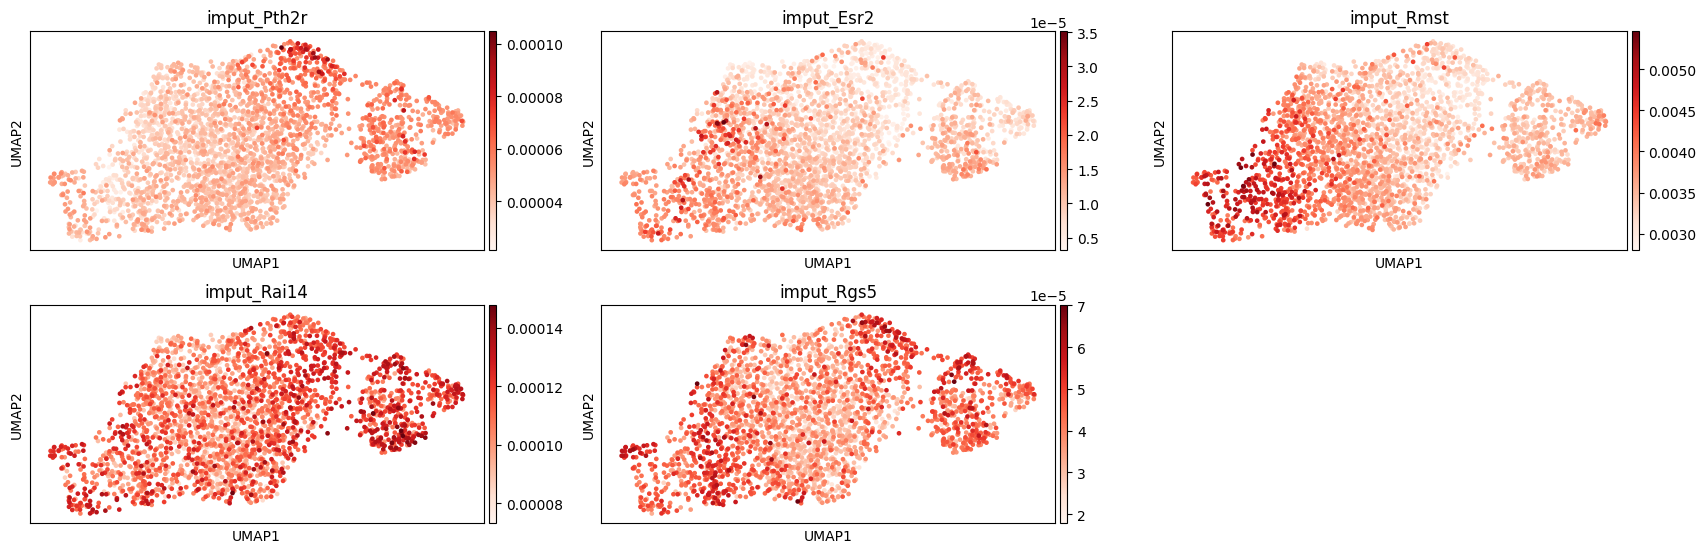

In [46]:
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = [f'imput_{g}' for g in adata_mer_imputed.uns['holdoff_genes']],           
           cmap='Reds',ncols=3)


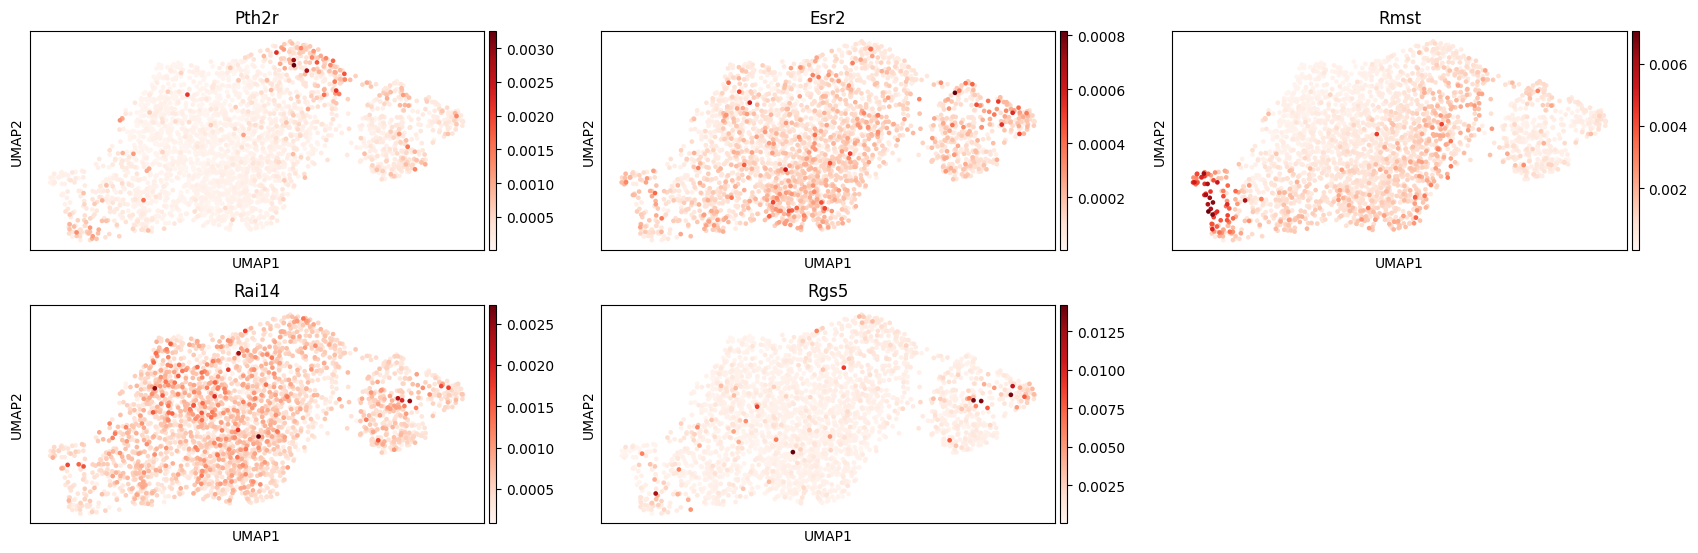

In [47]:

with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = adata_mer_imputed.uns['holdoff_genes'],           
           cmap='Reds',ncols=3)


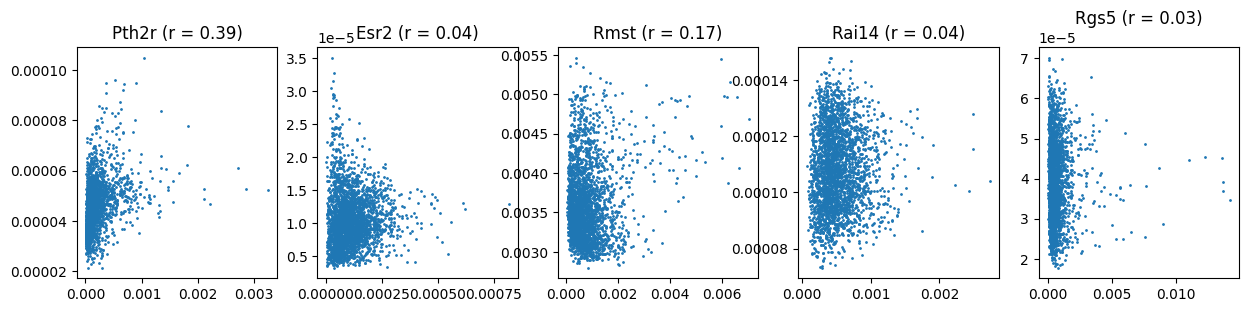

In [48]:
plt.figure(figsize = (3*n_holdoff_genes,3))
for i, tested_gene in enumerate(adata_mer_imputed.uns['holdoff_genes']):
    plt.subplot(1, n_holdoff_genes, i+1)
    x = adata_mer[:, tested_gene].X.flatten()
    y = adata_mer.obs['imput_' + tested_gene].values
    plt.scatter(x, y, s=1)
    
    corr_coef = np.corrcoef(x, y)[0, 1]    
    plt.title(f"{tested_gene} (r = {corr_coef:.2f})")

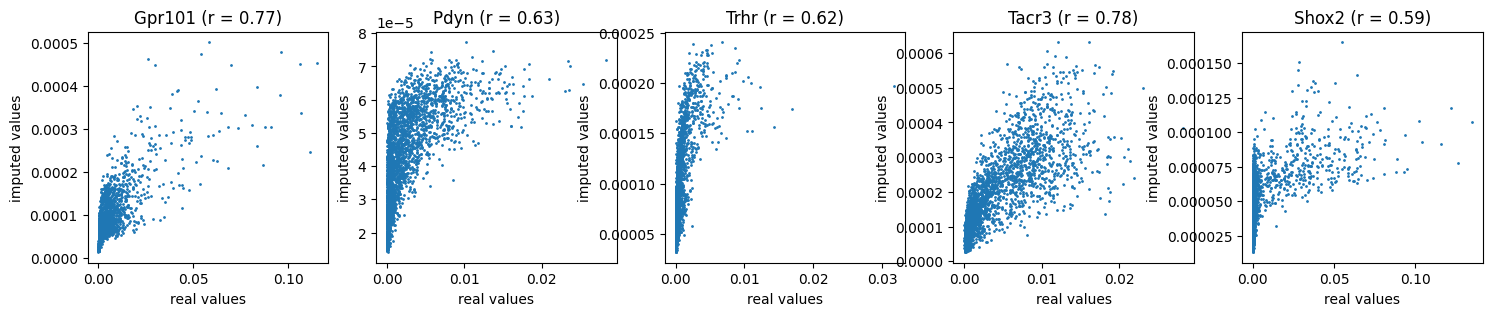

In [49]:
plt.figure(figsize = (18,3))
for i,tested_gene in enumerate(intersted_genes):
    plt.subplot(1,5,i+1)
    x = adata_mer[:, tested_gene].X.flatten()
    y = adata_mer.obs['imput_' + tested_gene].values
    plt.scatter(x, y, s=1)
    
    corr_coef = np.corrcoef(x, y)[0, 1]    
    plt.title(f"{tested_gene} (r = {corr_coef:.2f})")
    plt.ylabel('imputed values')
    plt.xlabel('real values')

# PC1 gradient genes

In [70]:
pos_grad_genes_list = ['Robo1','Il1rapl1','Htr2c']
neg_grad_genes_list = ['Dpp10','Dab1','Dach1']

In [71]:
adata_mer_imputed.obsm['X_umap'] = adata_mer.obsm['X_umap'].copy()

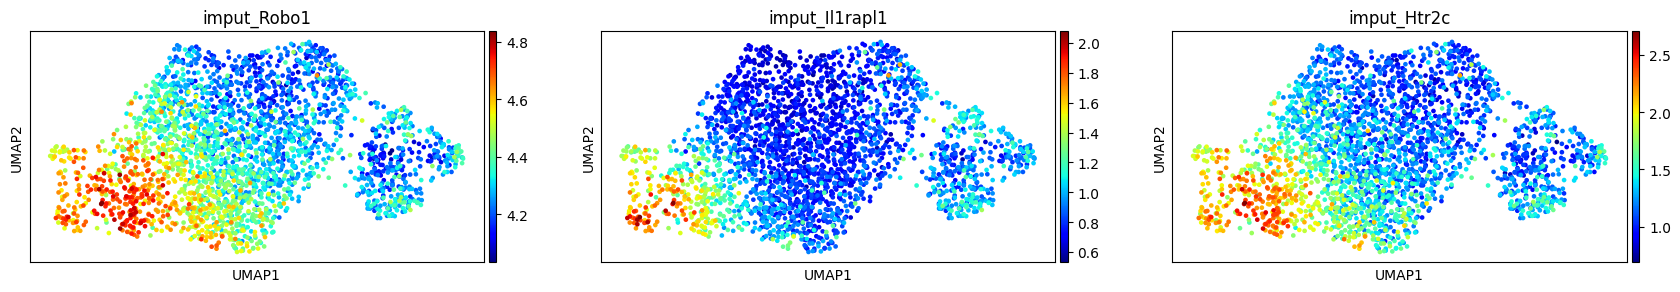

In [72]:

adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, pos_grad_genes_list)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = [f'imput_{g}' for g in pos_grad_genes_list],           
           cmap='jet',ncols=3)

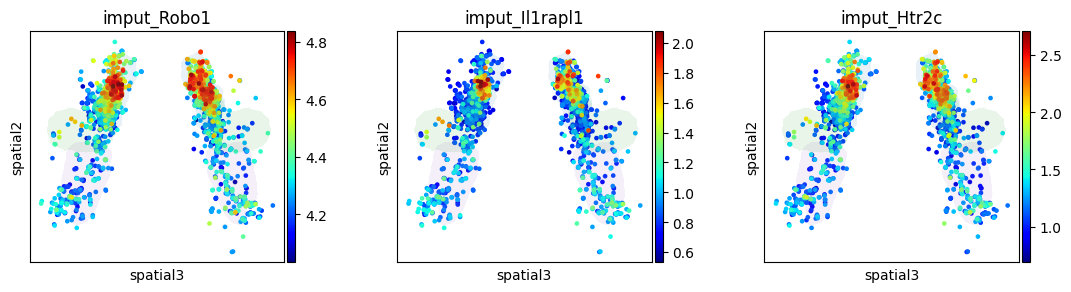

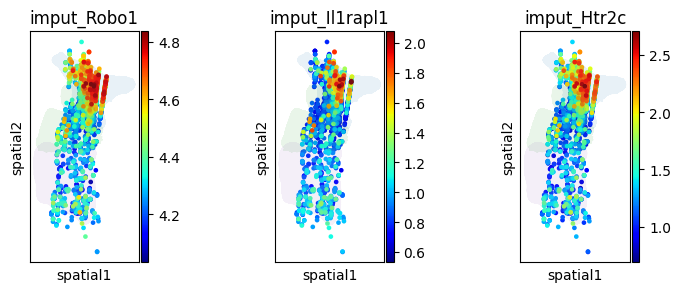

In [73]:
with plt.rc_context({"figure.figsize": (3.5,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),
           color = [f'imput_{g}' for g in pos_grad_genes_list],cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    plt.show()    
    
with plt.rc_context({"figure.figsize": (2,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(0,1),
           color = [f'imput_{g}' for g in pos_grad_genes_list[:3]],           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    plt.show()        

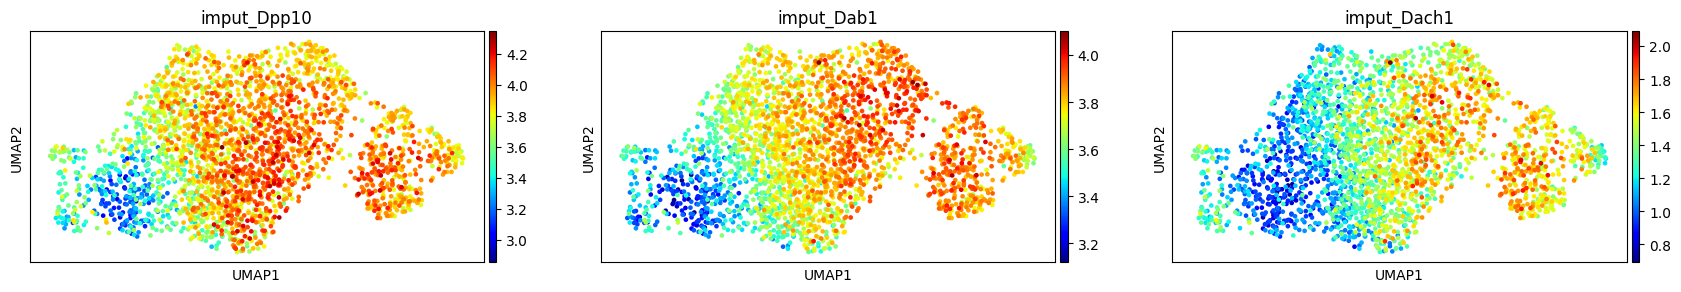

In [74]:
adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, neg_grad_genes_list)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3)

In [75]:
reordered =np.argsort(np.mean(adata_mer_imputed.obs[[f'imput_{g}' for g in neg_grad_genes_list]], 1))[::-1]
with plt.rc_context({"figure.figsize": (3.5,3)}):
    ax= sc.pl.embedding(adata_mer[reordered],basis='spatial',dimensions=(2,1),sort_order = False,
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    plt.show()    
    
with plt.rc_context({"figure.figsize": (2,3)}):
    ax= sc.pl.embedding(adata_mer[reordered],basis='spatial',dimensions=(0,1),sort_order = False,
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    plt.show()        

KeyError: "None of [Index(['imput_Dpp10', 'imput_Dab1', 'imput_Dach1'], dtype='object')] are in the [columns]"